In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from matplotlib.ticker import FormatStrFormatter
import pandas as pd
import os,sys
from pathlib import Path
current_dir = Path(os.getcwd()).resolve()
project_root = current_dir.parent
functions_path = project_root / "functions"
sys.path.append(str(functions_path))
import multiGP



## Radial velocities comparison plot
### S-BART, our pipeline, ESPRESSO pipeline and line-by-line

In [2]:
# Bin function

def phase_bin(phase, rv, rv_err):
    # Setup data
    phase = np.asarray(phase) % 1.0
    rv = np.asarray(rv)
    rv_err = np.asarray(rv_err)
    
    # Fixed spacing: 1.0 / 10 = 0.1 phase width per bin.
    n_bins = 10
    
    # Create equal-spaced bin edges
    bins = np.linspace(0, 1, n_bins + 1)
    # Use digitize to assign each point to a fixed-width bin
    digitized = np.digitize(phase, bins) - 1

    phase_binned, rv_binned, err_binned = [], [], []

    for i in range(n_bins):
        # Select points that fall into this specific phase window
        mask = digitized == i
        n_p = np.sum(mask)

        if n_p > 0:
            p_chunk = phase[mask]
            rv_chunk = rv[mask]
            err_chunk = rv_err[mask]

            # Weighted Mean RV (best estimate of the center)
            w = 1.0 / err_chunk**2
            rv_mean = np.sum(w * rv_chunk) / np.sum(w)
            
            # Weighted Phase Center 
            # (accounts for inhomogeneity within the equal-spaced bin)
            phase_center = np.sum(w * p_chunk) / np.sum(w)
            
            # Standard Error (The 68% confidence interval of the mean)
            if n_p > 1:
                std_error = np.std(rv_chunk) / np.sqrt(n_p)
                # Fallback if all points in bin are identical
                if std_error == 0:
                    std_error = np.sqrt(1.0 / np.sum(w))
            else:
                # Fallback for 1 point: use the instrumental error
                std_error = err_chunk[0]

            phase_binned.append(phase_center)
            rv_binned.append(rv_mean)
            err_binned.append(std_error)

    return np.array(phase_binned), np.array(rv_binned), np.array(err_binned)



# Planet Function
def planetmodel(theta,t, t0, per):
    
    krv, gamma, *_= theta 
    
    phase = (t-t0)/per
    rvmodel = -1 * krv * np.sin(2*np.pi * phase) + gamma

    return rvmodel


In [3]:
# import data from best fit output file for each pipeline (considering only RV model)

data_dir = "/home/ymascolo/Desktop/github/datasets" # path datsets

# (JSON_Path, RV_Col, RV_Err_Col, Label)
reductions = [
    (os.path.join(data_dir, "RV_best_fit_pipelines/rv_sbart.json"), "rv_bart", "rv_bart_err", "S-BART", "$\mathrm{K_{RV}=2.7\pm1.0 \,\,m\,s^{-1}}$", "$\mathrm{RMS=5.6 \,\,m\,s^{-1}}$"),
    (os.path.join(data_dir, "RV_best_fit_pipelines/rv_gz.json"), "rv_gz", "rv_gz_err", "Our pipeline", "$\mathrm{K_{RV}=2.5\pm1.0 \,\,m\,s^{-1}}$", "$\mathrm{RMS=5.4 \,\,m\,s^{-1}}$"),
    (os.path.join(data_dir, "RV_best_fit_pipelines/rv_esp.json"), "rv_esp", "rv_esp_err", "ESPR19", "$\mathrm{K_{RV}=3.1\pm1.5 \,\,m\,s^{-1}}$", "$\mathrm{RMS=8.2 \,\,m\,s^{-1}}$"),
    (os.path.join(data_dir, "RV_best_fit_pipelines/rv_lbl.json"), "rv_lbl", "rv_lbl_err", "LBL", "$\mathrm{K_{RV}=2.3\pm1.1 \,\,m\,s^{-1}}$", "$\mathrm{RMS=5.7 \,\,m\,s^{-1}}$")
]

data_file = os.path.join(data_dir, "ESPRESSO/RV_data.txt")

RMS S-BART: 5.546480260546208
RMS Our pipeline: 5.417196147989554
RMS ESPR19: 8.124303430471594
RMS LBL: 5.507709807036833


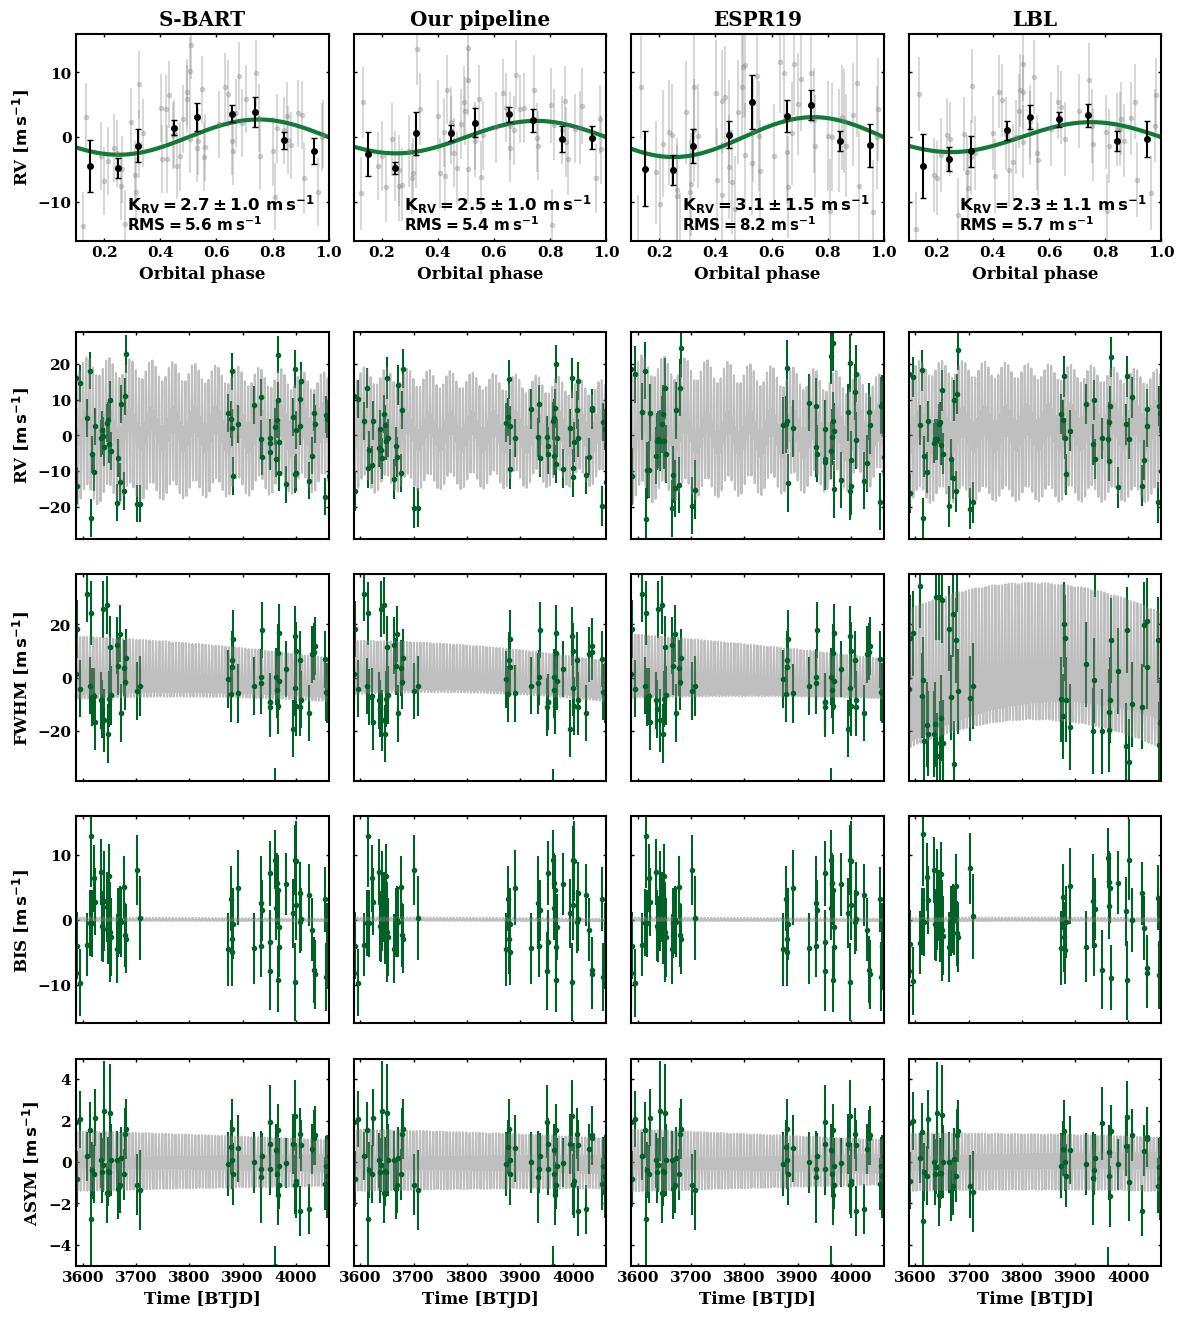

In [5]:
# PLOT
#====================

colors = sns.color_palette("Greens", 10)

fig = plt.figure(figsize=(14,16))
gs = fig.add_gridspec(
    6, 4,
    height_ratios=[1, 0.1, 1, 1, 1, 1],   # second row extra space
    wspace=0.1
)

axes = np.empty((5,4), dtype=object)

# mapping delle 5 righe reali
row_map = [0, 2, 3, 4, 5]

for i in range(5):
    for j in range(4):
        axes[i,j] = fig.add_subplot(gs[row_map[i], j])


plt.rcParams.update({
    "font.size": 12,
    "font.family": "serif",
    'font.weight': 'bold',        # Bold standard text
    'axes.labelweight': 'bold',   # Bold X and Y labels
    'axes.titleweight': 'bold',   # Bold Title
    'figure.titleweight': 'bold',  # Bold Figure title
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    'mathtext.fontset': 'custom',
    'mathtext.bf': 'sans:bold',
    'mathtext.rm': 'sans',
})


for col, (json_p, rv_col, rverr_col, label, K_label, RMS_label) in enumerate(reductions):
    
    # --- Data Extraction ---
    df_all = pd.read_csv(data_file, delim_whitespace=True)
    # Drop NaNs specific to the current RV reduction
    if rv_col=='rv_lbl':
        df = df_all.dropna(subset=['rv_lbl'])
    else: 
        df = df_all.dropna(subset=['rv_bart', 'rv_bart_err'])

    t = df['bjd'].values - 2457000
    rv = df[rv_col].values - np.mean(df[rv_col])
    rv_err = df[rverr_col].values
    
    # For FWHM and BIS, if they share the same column names across reductions:
    if rv_col=='rv_lbl':
        fwhm = df['fwhm_lbl'].values - np.mean(df['fwhm_lbl'])
        fwhm_err = df['fwhm_lbl_err'].values
    else:
        fwhm = df['fwhm_esp'].values - np.mean(df['fwhm_esp'])
        fwhm_err = df['fwhm_esp_err'].values
    bis = df['bis'].values - np.mean(df['bis'])
    bis_err = df['bis_err'].values
    asym = df['asym'].values - np.mean(df['asym'])
    asym_err = df['asym_err'].values

    # --- Parameter & GP Setup ---
    with open(json_p) as f:
        data = json.load(f)
    fp = data['fitted_parameters']

    # Extracting parameters (Mapping from your structure)
    theta_best = [fp[k]['median'] for k in [
        'krv', 'gamma', 'lam', 'P_{rot}', 'w', 
        'RV_{scale}', 'fwhm_{scale}', 'bis_{scale}', 'asym_{scale}',
        'RV_{dGdt\\,scale}', 'FWHM_{dGdt \\,scale}', 'asym_{dGdt \\,scale}', 
        'rv_{jitter}', 'fwhm_{jitter}', 'bis_{jitter}', 'asym_{jitter}'
    ]]
    
    t0, per, krv, gamma =  2164.354, 40.383, theta_best[0], theta_best[1]
    lam, prot, w = theta_best[2], theta_best[3], theta_best[4]
    RV_scale, fwhm_scale, bis_scale, asym_scale = theta_best[5], theta_best[6], theta_best[7], theta_best[8]
    RV_dGdt_scale, fwhm_dGdt_scale, asym_dGdt_scale  = theta_best[9], theta_best[10], theta_best[11]
    rv_jitter, fwhm_jitter, bis_jitter, asym_jitter =  theta_best[12], theta_best[13], theta_best[14], theta_best[15]

    # Setup GP Hyperparams and Vectors
    hp = multiGP.QPHyperParams(amp=1, lam=lam, P=prot, w=w)
    A = np.array([RV_scale, fwhm_scale, bis_scale,asym_scale])
    B = np.array([RV_dGdt_scale, fwhm_dGdt_scale, 0.0, asym_dGdt_scale])
    jitter = np.array([rv_jitter, fwhm_jitter, bis_jitter, asym_jitter])

    # 2. GP Predictions (Grid and Observed)
    t_list = [t, t, t,t]
    r_list = [rv - planetmodel(theta_best, t, t0, per), fwhm, bis, asym]
    err_list = [rv_err, fwhm_err, bis_err, asym_err]
    tgrid = np.linspace(t.min(), t.max(), 2000)
    t_star_list = [tgrid, tgrid, tgrid, tgrid]

    # Prediction on Grid
    mu_list, _ = multiGP.gp_predict_multidim(t_list, r_list, err_list, t_star_list=t_star_list, A=A, B=B, hp=hp, jitter=jitter)
    # Prediction on Observed
    mu_obs_list, _ = multiGP.gp_predict_multidim(t_list, r_list, err_list, t_star_list=t_list, A=A, B=B, hp=hp, jitter=jitter)
    
    mu_rv_grid, mu_fwhm_grid, mu_bis_grid, mu_asym_grid = mu_list[0], mu_list[1], mu_list[2], mu_list[3]
    mu_rv_obs = mu_obs_list[0]
    rvmodel_grid = planetmodel(theta_best, tgrid, t0,per)

    # calculaate RMS
    res = (rv - mu_rv_obs)*1e3
    std_wrms = np.std(res)
    print(f'RMS {label}:', std_wrms)


    #------------ PLOT --------------------


    for row in range(5):
        ax = axes[row, col]
        ax.grid(False)
        ax.set_facecolor('white')
        ax.tick_params(axis='both', which='major', labelsize=11,
            width=1, length=2, color='black', direction='in', top=True, right=True)
        
        # 1. Handle X-AXIS labels (columns)
        # We only want x-labels on Row 0 (Phase) and Row 4 (Time)
        if row not in [0, 4]:
            ax.set_xticklabels([])
            ax.set_xlabel("") # Ensure labels are cleared for middle row
        
        # 2. Handle Y-AXIS labels (rows)
        # We only want y-tick numbers for the first column (col == 0)
        if col > 0:
            ax.set_yticklabels([])

        for row_ax in axes[:, col]:
            for side in ['top', 'bottom', 'left', 'right']:
                row_ax.spines[side].set_linewidth(1.5)
                row_ax.spines[side].set_edgecolor('black')
        row_ax.grid(False)

    # ---------------------------------------------------------
    # ROW 0: RV Residual vs Phase
    # ---------------------------------------------------------
    phase_grid = np.linspace(0, 1, 200)
    sinusoid = -krv * np.sin(2 * np.pi * phase_grid)
    phase = ((t - t0) / per) % 1
    ph_bin, rv_bin, err_bin = phase_bin(phase, rv - mu_rv_obs, np.sqrt(rv_err**2 + rv_jitter**2))

    axes[0, col].errorbar(phase, (rv - mu_rv_obs-gamma)*1e3, yerr=(np.sqrt(rv_err**2 + rv_jitter**2))*1e3, fmt='.', alpha=0.3, color='grey', label='Data')
    axes[0, col].errorbar(ph_bin, (rv_bin-gamma)*1e3, yerr=err_bin*1e3, fmt="o", color='k', ms=4, label='Data binned', zorder=4, capsize=2)
    axes[0, col].plot(phase_grid, sinusoid*1e3, color=colors[8], lw=3, label='Sinusoidal')
    axes[0, col].set_title(f"{label}")
    if col == 0: axes[0, col].set_ylabel("RV [$\mathrm{m\,s^{-1}}$]")
    axes[0, col].set_xlabel("Orbital phase")

    axes[0, col].set_xlim(0.1, 1)
    axes[0, col].xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    axes[0, col].set_ylim(-16, 16)
    axes[0, col].text(0.2, 0.15, f"{K_label}", fontsize=12, transform=axes[0, col].transAxes)
    axes[0, col].text(0.2, 0.05, f"{RMS_label}", fontsize=11, transform=axes[0, col].transAxes)

    # ---------------------------------------------------------
    # ROW 1: RV vs Time
    # ---------------------------------------------------------
    axes[1, col].errorbar(t, rv*1e3, yerr=(np.sqrt(rv_err**2 + rv_jitter**2))*1e3, fmt='.', color=colors[9])
    axes[1, col].plot(tgrid, (mu_rv_grid + rvmodel_grid)*1e3, color='grey', alpha=0.5)
    if col == 0: axes[1, col].set_ylabel("RV [$\mathrm{m\,s^{-1}}$]")   
    axes[1, col].set_xlim(np.min(tgrid), np.max(tgrid))
    axes[1, col].set_ylim(-29, 29)

    # ---------------------------------------------------------
    # ROW 2: FWHM vs Time
    # ---------------------------------------------------------
    axes[2, col].errorbar(t, fwhm*1e3, yerr=(np.sqrt(fwhm_err**2 + fwhm_jitter**2))*1e3, fmt='.', color=colors[9])
    axes[2, col].plot(tgrid, mu_fwhm_grid*1e3, color='grey', alpha=0.5)
    if col == 0: axes[2, col].set_ylabel("FWHM [$\mathrm{m\,s^{-1}}$]")
    axes[2, col].set_ylim(-39, 39)
    axes[2, col].set_xlim(np.min(tgrid), np.max(tgrid))

    # ROW 3: Bisector vs Time
    # ---------------------------------------------------------
    axes[3, col].errorbar(t, bis*1e3, yerr=(np.sqrt(bis_err**2 + bis_jitter**2))*1e3, fmt='.', color=colors[9])
    axes[3, col].plot(tgrid, mu_bis_grid*1e3, color='grey', alpha=0.5)
    if col == 0: axes[3, col].set_ylabel("BIS [$\mathrm{m\,s^{-1}}$]")
    axes[3, col].set_ylim(-16, 16)
    axes[3, col].set_xlim(np.min(tgrid), np.max(tgrid))

    # ---------------------------------------------------------
    # ROW 4: Asym vs Time
    # ---------------------------------------------------------
    axes[4, col].errorbar(t, asym*1e3, yerr=(np.sqrt(asym_err**2 + asym_jitter**2))*1e3, fmt='.', color=colors[9])
    axes[4, col].plot(tgrid, mu_asym_grid*1e3, color='grey', alpha=0.5)
    if col == 0: axes[4, col].set_ylabel("ASYM [$\mathrm{m\,s^{-1}}$]")
    axes[4, col].set_xlabel("Time [BTJD]")
    axes[4, col].set_ylim(-5, 5)
    axes[4, col].set_xlim(np.min(tgrid), np.max(tgrid))

# plt.savefig('RV_comparison.pdf', dpi=300)
plt.show()